# 1. Quantum RNG (QRNG) oparty na fluktuacjach prozni

Dla przypomnienia: *By carefully measuring these vacuum fluctuations, we are able to generate ultra-high bandwidth random numbers. This means our random numbers are truly random, as guaranteed by the laws of quantum mechanics.*

### UPDATE

- Poprzednia wersja serwisu (sprzed migracji na AWS): https://qrng.anu.edu.au/contact/faq/#downloads
- Aktualna wersja serwisu (po migracji na AWS): https://quantumnumbers.anu.edu.au

Ze względu na limity API nie udało się pobrać próbki umożliwiającej rzetelne przetestowanie generatora. Wysłaliśmy zapytanie do zespołu badaczy **ANU QRNG** (The Australian National University, Quantum Random Number Generator) z prośbą o udostępnienie większej ilości danych w celu weryfikacji ich losowości. Na tę chwilę nie uzyskaliśmy odpowiedzi...  

Naukowa ciekawość nie pozwoliła nam jednak biernie czekać. Po zapoznaniu się z dokumentacją starej wersji serwisu okazało się, że kiedyś dostępne były uprzednio wygenerowane dane binarne o rozmiarach 10MB-5GB na dedykowanym serwerze (prawdopodobnie przewidziane właśnie do takich celów jak nasz). Niestety nie są już one dostępne, prawdopodobnie ze względu na migrację infrastruktury chmurowej serwisu. Stara wersja strony internetowej zawierała jednak link, pod którym można było pobrać próbkę danych o ustalonym rozmiarze w formie alfanumerycznej, heksadecymalnej lub binarnej. Okazało się, że każdorazowe odświeżenie strony zwraca inną zawartość...

Napisaliśmy więc skrypt do pobrania danych ze wskazanego linku. Nie natrafiliśmy na żadne ograniczenia w kontekście liczby zapytań. Pojedyncze zapytanie o dane w formie alfanumerycznej zwraca 1024 znaki, a więc ok. 768 bajtów (losowych?) danych. Prosty program wielowątkowy w kilka minut bez trudu pobrał ok. 800-850 kB danych. Wyniki zaprezentowane są poniżej.

In [1]:
from ipow.tests import ValidationConfig, validate_generator, run_visual_tests

import json

cfg = ValidationConfig(n_numbers=5000, n_bits=10000)

In [2]:
from ipow.generators import ANUVacuumQRNG

generator = ANUVacuumQRNG(
    max_workers=8,
    use_test_endpoint=True,
)

_ = generator._ensure_bytes(100_000)
stats = generator.download_stats()
print(stats)


Loaded 940032 bytes from cache at /home/kris/Studia/mgr-ist/semestr-3/ipow/projekt/noteboooks/quantum_cache.bin
{'session_requests': 0, 'session_downloaded': 0, 'current_ram_buffer': 940032, 'total_disk_cache_size': 940032}


In [3]:
results = validate_generator(
    generator,
    config=ValidationConfig(n_numbers=20_000, n_bits=100_000)
)
print(json.dumps(results, indent=2))

{
  "generator": "ANU Vacuum-Fluctuation QRNG (API)",
  "summary_numbers": {
    "count": 20000.0,
    "mean": 9.168203790577391e+18,
    "variance": 2.8046433577309085e+37,
    "std": 5.295888365261213e+18,
    "min": 624309538703799.0,
    "max": 1.844557568106752e+19
  },
  "summary_floats": {
    "count": 20000.0,
    "mean": 0.49760446385364376,
    "variance": 0.08272048636413909,
    "std": 0.28761169371939505,
    "min": 2.5394974718762064e-05,
    "max": 0.9999874264862851
  },
  "bit_balance": {
    "count": 100000,
    "zeros": 50299,
    "ones": 49701,
    "p_zero": 0.50299,
    "p_one": 0.49701
  },
  "serial_pairs": {
    "00": 25199,
    "01": 25099,
    "10": 25099,
    "11": 24602
  },
  "tests": {
    "monobit": {
      "statistic": 1.8910420407806907,
      "p_value": 0.058618732445465456,
      "pass": true
    },
    "runs": {
      "statistic": 50199.0,
      "p_value": 0.2041058774151844,
      "pass": true
    },
    "chi_square_uint64_mod_256": {
      "statist

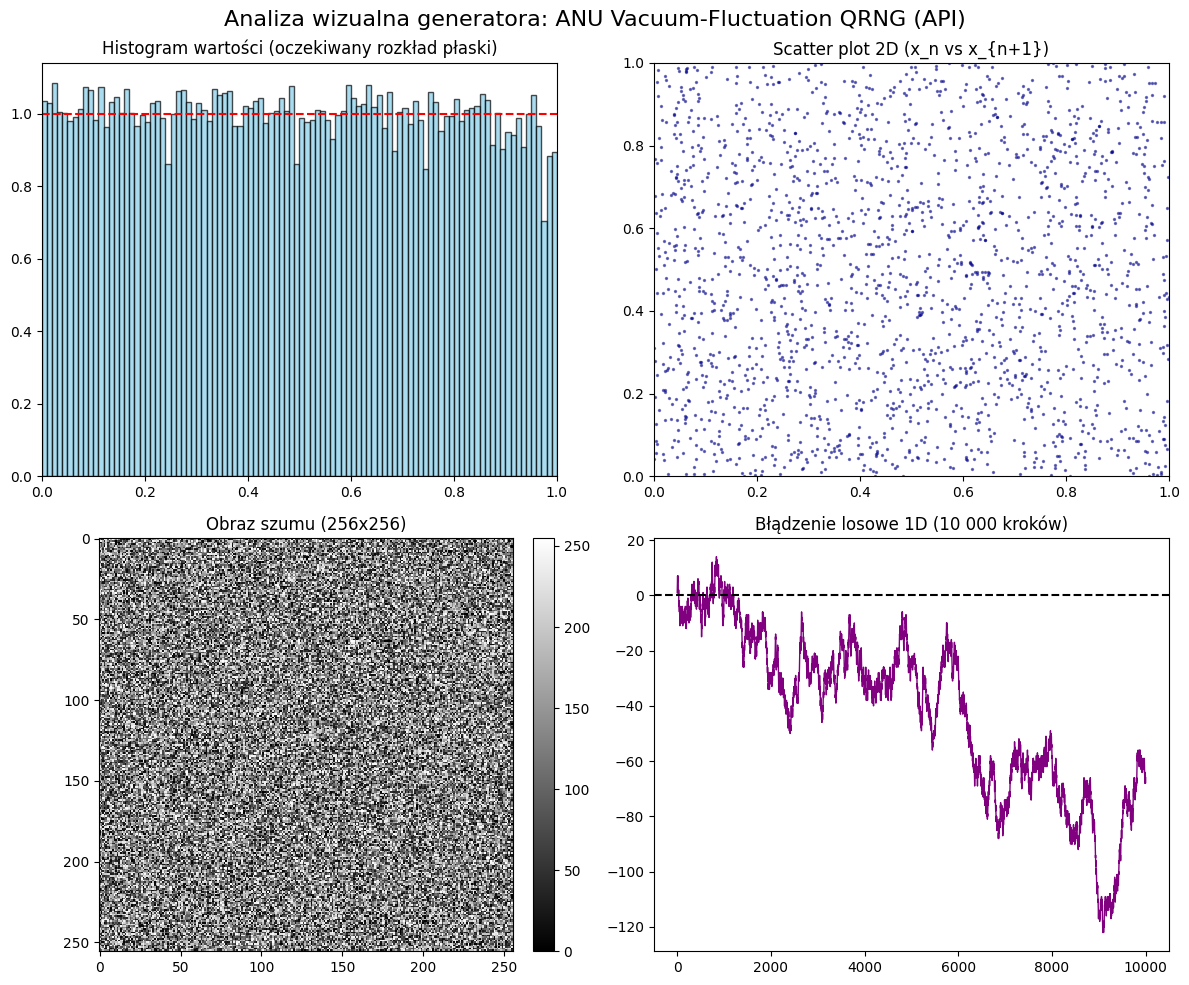

In [4]:
# Dla API sieciowego zmniejszamy liczbe probek, aby ograniczyc liczbe zapytan HTTP.
# run_visual_tests(generator, n_samples=1_792)
run_visual_tests(generator)

## 2. μRNG: A Non-Periodic Deterministic Random Number Generator

<img src="P9-images/urng_publication.png" style="width: 80%;">

Zupełnie inne podejście względem QRNG - czysta matematyka i teoria :)

Algorytm generowania liczb jest minimalistyczny i elegancki, a opiera się na teorii liczb, w szczególności liczb p-adycznych.

Niech $p$ - liczba pierwsza. Liczba $p$-adyczna to obiekt postaci:  
\[nieskończony ciąg cyfr\],\[skończony ciąg cyfr\]  
gdzie "cyfry" to elementy zbioru \{0,1,...,p-1\}.

W dalszej części skupimy się na liczbach 2-adycznych.

W "zwykłej" matematyce liczby są blisko siebie, jeśli ich różnica jest mała (np. 0,001). Jest to standardowa, intuicyjna dla nas miara bliskości liczb. W przypadku liczb 2-adycznych, ze względu na nieskończony ciąg cyfr na bardziej znaczących miejscach, liczby są blisko siebie, jeśli ich różnica jest podzielna przez wysoką potęgę dwójki.

Należy myśleć o tym następująco:
- Jeśli wiemy, że ostatni bit pewnej liczby 2-adycznej to 0, to wiemy o niej niewiele.
- Jeśli wiemy, że dana liczba ma 100 ostatnich bitów równych 0, czyli jest podzielna przez $2^{100}$, to w świecie 2-adycznym jest ona bardzo bliska zeru (niezależnie od dalszych bitów na bardziej znaczących miejscach!), bo "udaje" zero na długim odcinku.

Taki świat, w którym pozwalamy liczbom mieć nieskończenie wiele bitów w lewą stronę (pierścień liczb 2-adycznych???) to idealne środowisko dla generatorów, bo operujemy na bitach, które "nigdy się nie kończą".

Algorytm próbuje rozwiązać stosunkowo proste zadanie: **"zgaś" wszystkie bity ziarna $s$, używając potęg szóstki.**

Intuicyjnie, jeśli ziarno ma pewne bity (np. `...10110`), algorytm:
1. patrzy na ostatni bit. Jeśli jest tam `1`, dodaje aktualną potęgę szóstki ($6^n$), żeby "zgasić" ten bit (zamienić go w `0`).
2. zapisuje daną decyzję - jeśli dodał $6^n$, to bit ustala kolejny bit generatora na $1$, jeśli nie - $0$.
3. przechodzi do następnego bitu (dzielenie przez 2, tzn. przesunięcie bitowe `>> 1`).

Pojawia się szereg: $A=s+a_0​^60+a_1​6^1+a_2​6^2+\ldots$, którego suma w paradygmacie 2-adycznym ma dążyć do zera (suma ma mieć coraz więcej zer po prawej stronie).

#### Dlaczego w takim razie używać $6^n$, a nie po prostu $2^n$?

Gdybyśmy używali $2^n$ do "gaszenia" bitów, to bity generatora byłyby de facto bitami ziarna - zero losowości!  
Skoro jednak $6^n = 2^n\cdot3^n$, to wciąż możemy "gasić" bity (bo mamy czynnik $2^n$), ale jednocześnie wprowadzamy szum czynnikiem $3^n$.

W systemie binarnym mnożenie przez 3 to `t + (t << 1)`. To powoduje, że przy próbie "zgaszenia" bitu na pozycji $n$, wprowadzane jest "zamieszanie" na wszystkich pozycjach po lewej stronie (na pozycjach $n+1, n+2, \ldots$ licząc od prawej strony).

Przykład "mieszania":
1. Chcemy wyzerować bit nr 5.
2. Dodajemy $6^5$.
3. Czynnik $2^5$ zeruje bit nr 5, ale czynnik $3^5$ "rozpryskuje" jedynki na wyższe bity.
4. Te "rozpryśnięte" bity zmieniają to, co generator zrobi w krokach 6, 7, 8...

To powoduje deterministyczny chaos.

#### Na czym polega nieperiodyczność?

W publikacji autor przedstawia dowód (bardziej w formie szkicu matematycznego) na to, że ten generator nie jest periodyczny. Idea dowodu opiera się na sprzeczności...

#### PROBLEM: wydajność

W kodzie zmienna `t` przechowuje czynnik $3^n$. Skoro w każdym kroku odbywa się mnożenie przez 3, to dla $n=1000$ mamy $t=3^{1000}$. W systemie binarnym ta liczba staje się coraz dłuższa, przez co Python musi radzić sobie z liczbami, które mają miliony bitów. W innych generatorach (np. ChaCha20) dzięki stosowaniu operacji modulo nie ma tego problemu. Mimo, że Python potrafi obsługiwać dowolnie duże liczby całkowite, to operacje na nich (dodawanie i przesuwanie bitowe) zajmują coraz więcej czasu procesora wraz ze wzrostem liczby cyfr. Z tego powodu, standardowe wykonanie funkcji generującej wizualizację losowości generatora, trwało ponad godzinę!

#### Implementacja

Funkcja mieści się w czterech liniach kodu języka Python, co jest imponującym wynikiem:
```py
def uRNG(s,n):
    r,t=[],1
    for _ in range(n): s=(s+(s&1)*t)>>1; t+=t<<1; r+=[s&1]
    return r
```

Warto jednak zauważyć, że choć generator przechodzi testy statystyczne NIST, autor nie wspomina o bezpieczeństwie kryptograficznym. Po konsultacji osobistej okazało się, że znając początek wygenerowanego ciągu liczb i mając informację o długości ziarna można odtworzyć kolejne wartości. Należy więc traktować ten generator raczej jako ciekawostkę, niż kandydata do zastosowań kryptograficznych.

{
  "generator": "\u00b5RNG",
  "summary_numbers": {
    "count": 1000.0,
    "mean": 9.031677158702711e+18,
    "variance": 2.885077306410837e+37,
    "std": 5.371291563870683e+18,
    "min": 1.2746973646764308e+16,
    "max": 1.8437325130881823e+19
  },
  "summary_floats": {
    "count": 1000.0,
    "mean": 0.4932926658607141,
    "variance": 0.08408423506228176,
    "std": 0.28997281779898226,
    "min": 0.0015674419469785539,
    "max": 0.9998533938583396
  },
  "bit_balance": {
    "count": 5000,
    "zeros": 2564,
    "ones": 2436,
    "p_zero": 0.5128,
    "p_one": 0.4872
  },
  "serial_pairs": {
    "00": 1319,
    "01": 1244,
    "10": 1244,
    "11": 1192
  },
  "tests": {
    "monobit": {
      "statistic": 1.8101933598375617,
      "p_value": 0.07026580698642185,
      "pass": true
    },
    "runs": {
      "statistic": 2489.0,
      "p_value": 0.7910405244774634,
      "pass": true
    },
    "chi_square_uint64_mod_256": {
      "statistic": 233.92000000000002,
      "p_v

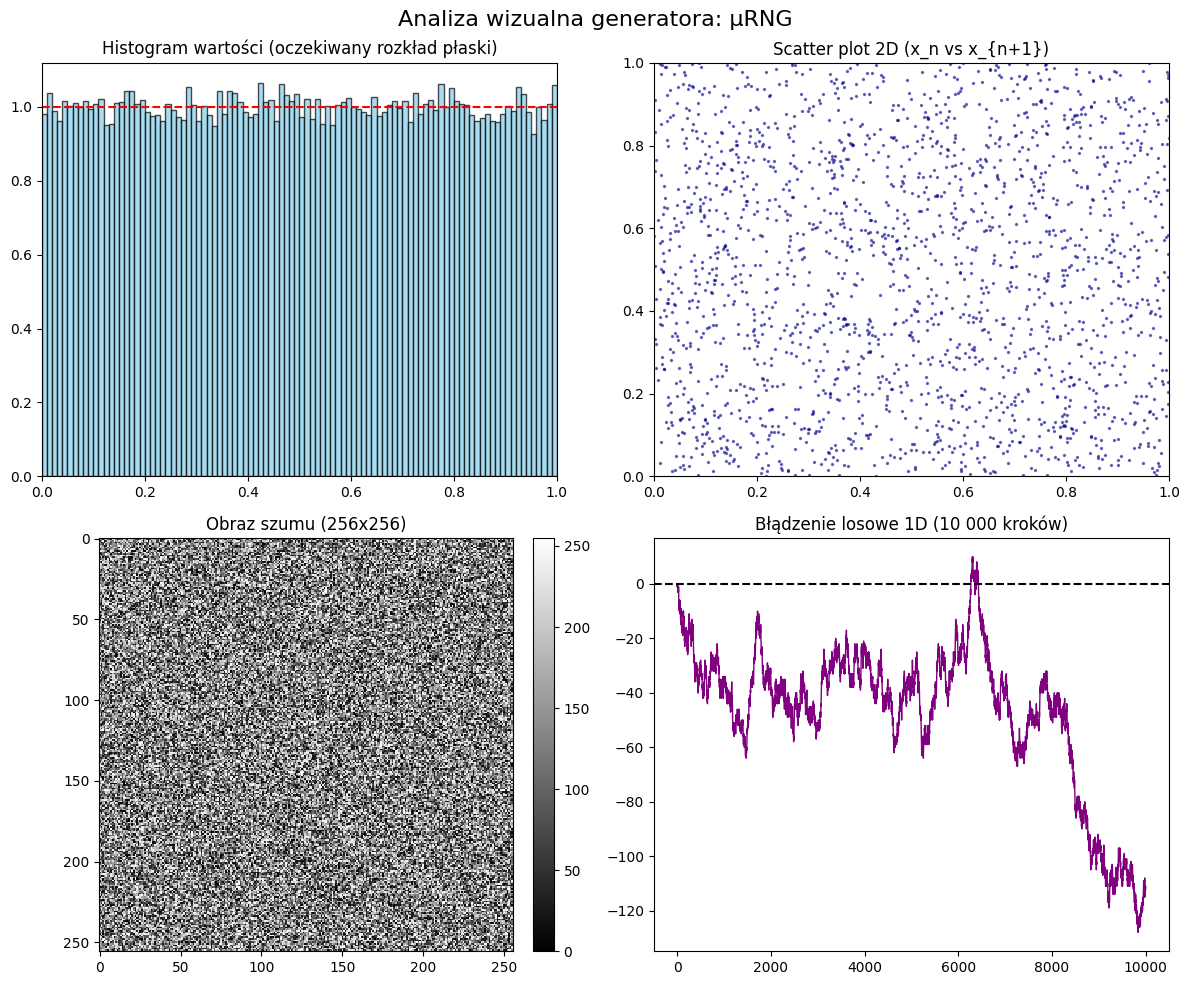

In [7]:
from ipow.generators import URNG

generator = URNG(seed=2)

results = validate_generator(
    generator,
    config=ValidationConfig(n_numbers=1000, n_bits=5000)
)
print(json.dumps(results, indent=2))

run_visual_tests(generator)